# Portfolio and housing guidance from one lifecycle model

Most digital investment tools set a customer's equity share from age and a risk
questionnaire, and treat the family home as if it belonged to someone else's
balance sheet. For most households the home is the largest asset they will ever
hold, so guidance that ignores it misjudges how much market risk the customer
can actually afford. This notebook demonstrates an engine that treats the two
decisions as one problem: a lifecycle model of saving, home purchase, and
portfolio choice, solved jointly, that returns a recommended equity share *and*
a housing action for a customer described by age, wealth, housing status, and
risk profile.

The approach follows the research agenda set out in *Life-Cycle Modeling is
(Almost) Ready for Prime Time* (Carroll et al., Econ-ARK / T. Rowe Price): use
estimated structural lifecycle models — rather than rules of thumb — as the
engine behind personalized financial guidance. In that spirit, the risk
profiles below are anchored to that project's estimates of risk aversion, and
the model's recommendations are benchmarked throughout against the S&P Target
Date glide path that practitioners already use.

Everything here runs in a few seconds on a laptop. Section 6 spells out what is
demonstration-scale and what the production version does differently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import demo_model as dm

INK, SUB, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
COLORS = {"Growth": "#2a78d6", "Balanced": "#1baf7a", "Conservative": "#eda100"}
BENCH = "#52514e"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5,
    "axes.edgecolor": SUB, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "xtick.color": SUB, "ytick.color": SUB, "legend.frameon": False,
})

SHOW = dm.AGES <= 80          # display window; the last model years are
                              # dominated by the terminal bequest value

def endlabel(ax, x, y, text, color, dx=0.6, dy=0.0):
    ax.annotate(text, (x, y), xytext=(x + dx, y + dy), fontsize=9.5,
                color=color, fontweight="bold", va="center")

We solve the model once for each of three risk profiles and simulate 10,000
households per profile. The profiles differ only in risk aversion:
**Conservative** uses the *Prime Time* project's estimate for a standard
lifecycle model (γ = 8), **Balanced** uses its estimate when a bequest motive
is included (γ = 4.65), and **Growth** uses a more risk-tolerant value chosen
for contrast (γ = 3, in the range common in the literature rather than an
estimate). Every other parameter is identical across profiles.

In [2]:
policies, values, panels, glide = {}, {}, {}, {}
for name, gamma in dm.TYPES.items():
    policies[name], values[name] = dm.solve_lifecycle(gamma)
    panels[name] = dm.simulate(policies[name])
    glide[name] = dm.share_profile(panels[name])
print("solved and simulated:", ", ".join(policies))

solved and simulated: Growth, Balanced, Conservative


## 1. The guidance in one look

The chart below is the engine's core output. Each solid line is the average
recommended share of financial wealth in equities, by age, for one risk
profile; the dashed line is the S&P Target Date glide path that a
target-date fund would apply to everyone.

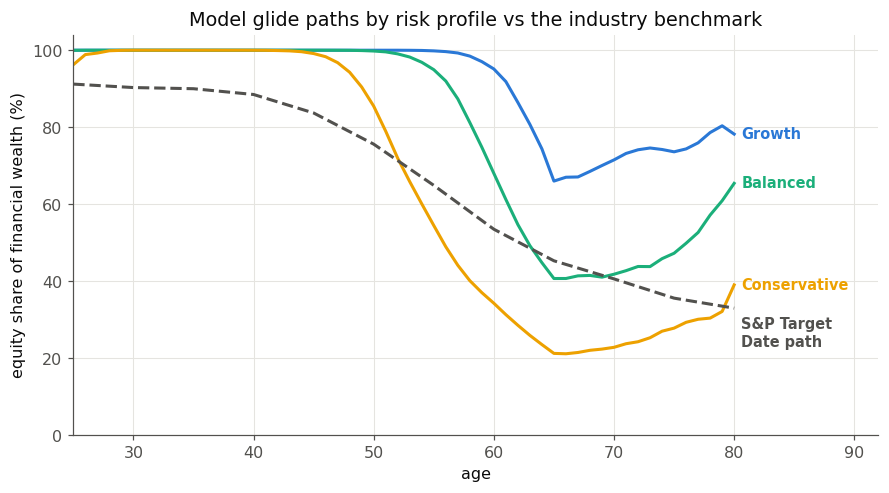

In [3]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
for name in dm.TYPES:
    ax.plot(dm.AGES[SHOW], 100 * glide[name][SHOW], color=COLORS[name], lw=2)
    endlabel(ax, 80, 100 * glide[name][SHOW][-1], name, COLORS[name])
sp = dm.SP_AGES <= 80
ax.plot(dm.SP_AGES[sp], 100 * dm.SP_EQUITY[sp], "--", color=BENCH, lw=2)
endlabel(ax, 80, 100 * dm.SP_EQUITY[sp][-1], "S&P Target\nDate path", BENCH, dy=-6.5)
ax.set_xlim(25, 92); ax.set_ylim(0, 104)
ax.set_xlabel("age"); ax.set_ylabel("equity share of financial wealth (%)")
ax.set_title("Model glide paths by risk profile vs the industry benchmark")
plt.tight_layout(); plt.show()

Three things stand out. First, the Conservative profile reproduces the broad
shape of the industry glide path — high equity while young, de-risking through
the 50s — which is reassuring, since the *Prime Time* estimate of γ = 8 was
obtained by asking what level of risk aversion best explains observed saving behavior.
Second, the model keeps all profiles fully invested longer than the benchmark:
while working years remain, salary acts like a bond holding, so the *financial*
portfolio can afford to carry the equity risk. Third, after retirement the
recommended share drifts back up — as savings are spent down, the pension
(again bond-like) comes to dominate the household balance sheet, leaving room
for equity risk in what remains. A single glide path applied to everyone can
capture none of these distinctions.

The same solved model doubles as a guidance engine for individual
customers. The first two below are identical in every respect — age 38,
Balanced profile, seven times earnings in financial wealth — except that one
rents and one owns the starter home; no age-based product can tell them
apart:

In [4]:
def illustrate_plan(age, wealth, rung, profile):
    """Guidance illustration for one customer (wealth in multiples of
    average annual earnings; rung 0 = renting)."""
    t = age - 25
    ih = int(np.argmin(np.abs(dm.H_LADDER - rung)))
    iz = dm.NZ // 2
    share = np.interp(wealth, dm.a_grid, policies[profile]["share"][t, :, ih, iz])
    Rp = dm.R_F + share * (np.exp(dm.MU_R) - dm.R_F)   # a typical (median) market year
    ib = min(np.searchsorted(dm.b_grid, wealth * Rp), dm.NB - 1)
    move = policies[profile]["branch"][t, ib, ih, iz] > 0
    dest = policies[profile]["rung"][t, ib, ih, iz]
    action = ("keep current housing" if not move else
              f"move to the {['rental', 'starter home', 'family home', 'premium home'][dest]}")
    print(f"  {profile}, age {age}, wealth {wealth:.1f}x earnings, "
          f"{'renting' if rung < 1 else 'owner'}:")
    print(f"    equity share {100*share:.1f}%  |  housing (in a typical market year): {action}")

for cust in [(38, 7.0, 0.25, "Balanced"), (38, 7.0, 1.0, "Balanced"),
             (58, 8.0, 2.5, "Conservative")]:
    illustrate_plan(*cust)

  Balanced, age 38, wealth 7.0x earnings, renting:
    equity share 87.9%  |  housing (in a typical market year): move to the starter home
  Balanced, age 38, wealth 7.0x earnings, owner:
    equity share 100.0%  |  housing (in a typical market year): keep current housing
  Conservative, age 58, wealth 8.0x earnings, owner:
    equity share 47.0%  |  housing (in a typical market year): keep current housing


These are illustrations of model output, not personal financial advice: the
intended use is as a decision-support engine sitting behind a licensed adviser
or an authorized digital-advice product, where suitability, disclosure, and
review obligations are handled by the surrounding process.

## 2. Housing and wealth by risk profile

Housing decisions come out of the same model. The left panel shows the share
of each profile that owns a home (starter rung or above) by age, against the
published US ownership-by-age pattern; the right panel shows median financial
wealth.

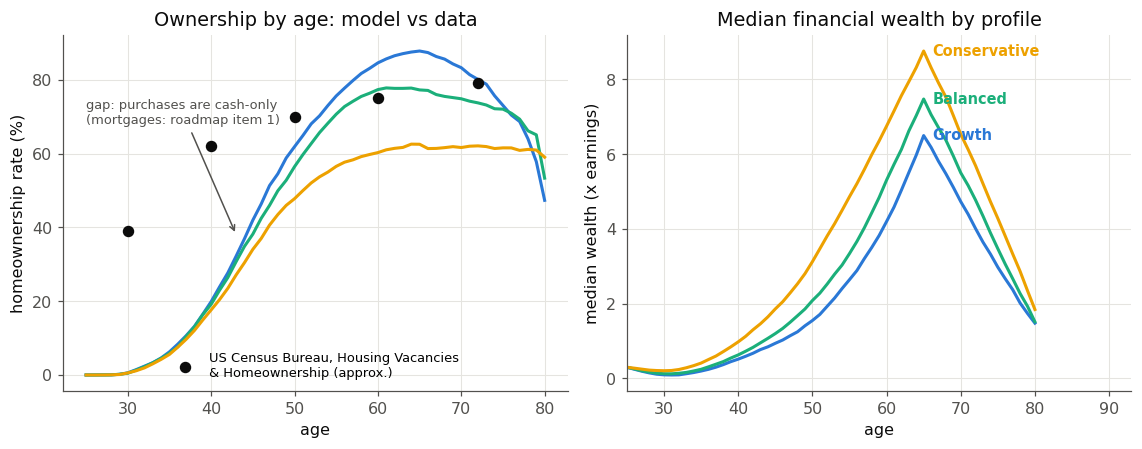

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for i, name in enumerate(dm.TYPES):
    axes[0].plot(dm.AGES[SHOW], 100 * panels[name]["own"].mean(axis=1)[SHOW],
                 color=COLORS[name], lw=2)
    medw_n = np.median(panels[name]["assets"], axis=1)
    axes[1].plot(dm.AGES[SHOW], medw_n[SHOW], color=COLORS[name], lw=2)
    endlabel(axes[1], 65, medw_n[40], name, COLORS[name], dx=1.2)
axes[0].scatter(dm.CENSUS_AGE_MID, 100 * dm.CENSUS_OWN, s=42, color=INK,
                zorder=5, label="US Census Bureau, Housing Vacancies\n& Homeownership (approx.)")
axes[0].legend(loc="lower center", fontsize=8.5)
axes[0].annotate("gap: purchases are cash-only\n(mortgages: roadmap item 1)",
                 (43, 38), xytext=(25, 68), fontsize=8.5, color=SUB,
                 arrowprops=dict(arrowstyle="->", color=SUB, lw=1.0))
axes[0].set_xlabel("age"); axes[0].set_ylabel("homeownership rate (%)")
axes[0].set_title("Ownership by age: model vs data")
axes[1].set_xlim(25, 93)
axes[1].set_xlabel("age"); axes[1].set_ylabel("median wealth (x earnings)")
axes[1].set_title("Median financial wealth by profile")
plt.tight_layout(); plt.show()

The model's ownership profile matches the published pattern from the
mid-50s on; entry is too late at younger ages because purchases here are
cash-only — a buyer must hold the full house price in financial wealth —
which is precisely why mortgages head the roadmap in Section 5. Beyond that
timing difference, home purchase
here is a genuine decision (with a 12% transaction cost on top of the
price), so ownership timing responds to wealth, income prospects, and risk
appetite. More risk-averse households save more (in this preference
family risk aversion and the strength of precautionary saving travel together,
a point we return to in Section 6), which is why the Conservative wealth
profile sits highest.

The interaction between the two decisions is easiest to see in the
recommendations themselves. The next chart fixes age 38 and median income, and plots
the recommended equity share as a function of wealth for two otherwise
identical Balanced customers: one renting, one already owning the starter
home.

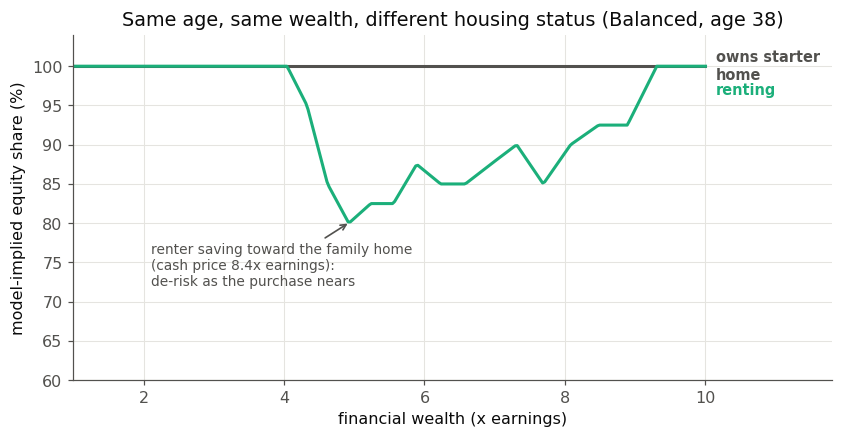

In [6]:
t38, iz = 38 - 25, dm.NZ // 2
w = np.linspace(1, 10, 300)
sh_rent = np.interp(w, dm.a_grid, policies["Balanced"]["share"][t38, :, 0, iz])
sh_own = np.interp(w, dm.a_grid, policies["Balanced"]["share"][t38, :, 1, iz])
fig, ax = plt.subplots(figsize=(7.8, 4.1))
ax.plot(w, 100 * sh_own, color=SUB, lw=2)
ax.plot(w, 100 * sh_rent, color=COLORS["Balanced"], lw=2)
endlabel(ax, w[-1], 100 * sh_own[-1], "owns starter\nhome", SUB, dx=0.15)
endlabel(ax, w[-1], 100 * sh_rent[-1] - 3, "renting", COLORS["Balanced"], dx=0.15)
dip = w[np.argmin(sh_rent)]
ax.annotate("renter saving toward the family home\n(cash price 8.4x earnings):"
            "\nde-risk as the purchase nears",
            (dip, 100 * sh_rent.min()), xytext=(2.1, 72), fontsize=9, color=SUB,
            arrowprops=dict(arrowstyle="->", color=SUB, lw=1.1))
ax.set_xlim(1, 11.8); ax.set_ylim(60, 104)
ax.set_xlabel("financial wealth (x earnings)")
ax.set_ylabel("model-implied equity share (%)")
ax.set_title("Same age, same wealth, different housing status (Balanced, age 38)")
plt.tight_layout(); plt.show()

The gap between the two lines is the **down-payment effect**: a renter
approaching the wealth needed for the family home has a large, dated
expenditure ahead, and the model shields it from market risk — up to twenty
percentage points less equity than an owner with the *same* age, income, and
wealth — then re-risks once the purchase is behind them (the small steps to the
right of the dip trace the discrete rungs of the demonstration's housing
ladder; the production engine's continuous-housing solver smooths them
away). No age-only glide path can produce this pattern, because it turns on wealth and housing status
rather than age; it is exactly the kind of guidance that requires the two
decisions to be solved together.

Because the profiles accumulate different amounts of wealth, part of the
difference between the age profiles above reflects different balance sheets
rather than different attitudes to risk.
The cleanest preference comparison holds the balance sheet fixed: the chart
below re-computes the recommended share at every age for the *same* customer
(the pooled median wealth path, renting-or-owning at the pooled modal rung).

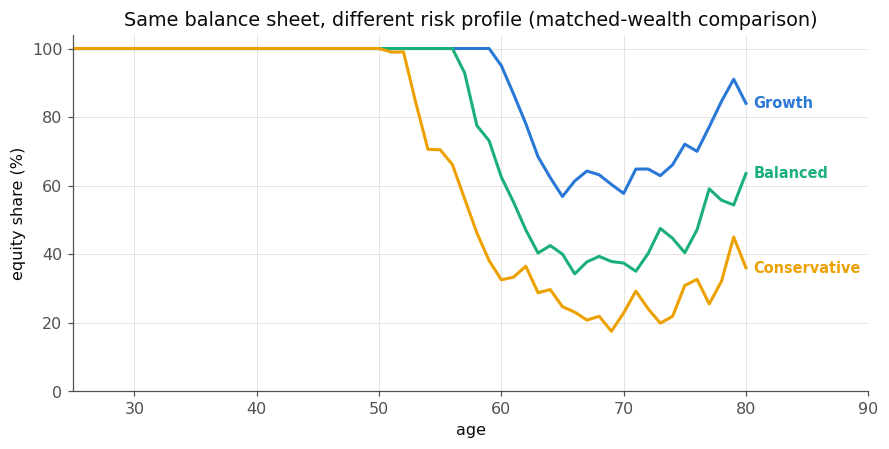

In [7]:
pooled_assets = np.concatenate([panels[n]["assets"] for n in dm.TYPES], axis=1)
pooled_house = np.concatenate([panels[n]["house"] for n in dm.TYPES], axis=1)
medw = np.median(pooled_assets, axis=1)
rung_idx = np.searchsorted(dm.H_LADDER, pooled_house - 1e-9).clip(0, dm.NH - 1)
modal_rung = np.array([np.bincount(rung_idx[t], minlength=dm.NH).argmax()
                       for t in range(dm.T)])
fig, ax = plt.subplots(figsize=(8.2, 4.2))
for name in dm.TYPES:
    s = np.array([np.interp(medw[t], dm.a_grid,
                  policies[name]["share"][t, :, modal_rung[t], dm.NZ // 2])
                  for t in range(dm.T)])
    ax.plot(dm.AGES[SHOW], 100 * s[SHOW], color=COLORS[name], lw=2)
    endlabel(ax, 80, 100 * s[SHOW][-1], name, COLORS[name])
ax.set_xlim(25, 90); ax.set_ylim(0, 104)
ax.set_xlabel("age"); ax.set_ylabel("equity share (%)")
ax.set_title("Same balance sheet, different risk profile (matched-wealth comparison)")
plt.tight_layout(); plt.show()

Held to the same balance sheet, the three profiles still separate sharply
from the early 50s: at 70, the Growth customer is advised toward roughly
60% equity against roughly 20% for the Conservative one. That gap is pure
risk attitude — wealth, housing, income, and age are identical by
construction — and it is the quantity a risk questionnaire is meant to
capture but cannot act on.

## 3. What the guidance is worth

A natural question is how much better off a customer is under the model's
recommendation than under the one-size-fits-all benchmark. We re-solve each
profile with the equity share *forced* to follow the S&P Target Date path at
every age — leaving spending and housing decisions optimal — and express the
welfare difference as a permanent percentage of lifetime consumption (a certainty-equivalent;
with housing and bequest terms in preferences the conversion is approximate,
and errs on the conservative side).

In [8]:
print(f"{'profile':14s} {'CE gain':>9s}   {'per $100k of lifetime spending':>32s}")
for name, gamma in dm.TYPES.items():
    lam = dm.value_of_guidance(gamma, values[name])
    print(f"{name:14s} {100*lam:8.2f}%   {'$' + format(1000*lam*100, ',.0f'):>32s} per year")

profile          CE gain     per $100k of lifetime spending


Growth             0.37%                               $373 per year


Balanced           0.17%                               $170 per year


Conservative       0.21%                               $208 per year


The gains — 17 to 37 basis points of lifetime spending per year — are
modest for the Balanced profile, since the industry glide path is a
reasonable average prescription, and largest where the customer is furthest
from average. They are also a floor: the benchmark customer in this
comparison still receives the model's saving and housing guidance, which no
target-date product provides — only the equity-share margin is being priced
here. That is the business case for personalization in one table: a standard
product serves the middle of the distribution well, and a model-based engine
serves the tails.

## 4. How the engine works

Under the hood, a year in a customer's life is a short sequence of decision
steps: a **portfolio step** (split financial wealth between a safe and a risky
asset; the market return then realizes), a **housing step** (keep the current
home, or sell and buy another rung on the ladder; the year's income then
realizes), and a **spending step** (consume or save out of cash on hand). The
plan is computed by working backwards from retirement, so each year's
recommendation already anticipates every later decision — including, for
example, next decade's home purchase.

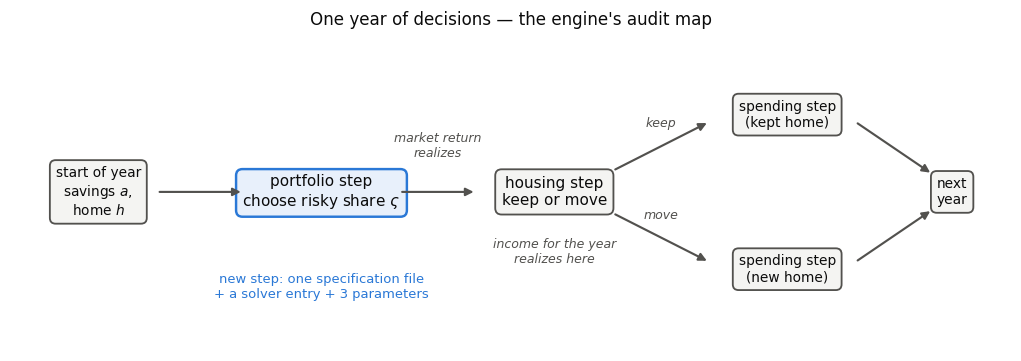

In [9]:
fig, ax = plt.subplots(figsize=(9.4, 3.4))
dm.draw_blueprint(ax)
ax.set_title("One year of decisions — the engine's audit map", fontsize=11)
plt.tight_layout(); plt.show()

This diagram is not just documentation: the production engine is generated
directly from a plain-text description with exactly this structure — each
box is a short file stating what is chosen, what is uncertain, and how the
customer's position carries into next year. The portfolio step shown here slots into the existing housing-and-spending
blueprint as one new specification file plus a solver-method entry and
three parameters (the safe rate, the average equity return, and its
volatility); the existing decision files are untouched. New product features — a mortgage, an annuity, a tax wrapper
— enter the same way, which is what keeps the engineering cost of
personalization low, and the resulting decision logic auditable step by step
for compliance review.

The demonstration in this notebook re-implements that structure at laptop
scale. The production stack solves the same design with research-grade
numerics (fast upper-envelope methods for the housing kinks — Dobrescu and
Shanker's FUES — on grids of 600 points per continuous dimension, against 80
here) and estimates its parameters by matching simulated behavior to
household data; one full lifecycle plan at production grids computes in a few minutes on a
single core, and an estimation run — about a thousand candidate models per
step — costs a few thousand CPU-hours on a national research supercomputer.

## 5. From demonstration to product

The natural build-out, in order:

1. **Mortgages and collateralized borrowing** — the single most important
   missing feature; it enters as one more decision step on the same map.
2. **Fees and taxes** — returns here are gross; asset-location guidance
   (which account holds which asset) is a step of the same kind.
3. **More customer characteristics** — income risk by occupation, family
   size, bequest intentions; each is a parameter the estimation pipeline can
   pin down with data rather than a questionnaire alone.
4. **Estimated, not assumed, preferences** — the *Prime Time* program shows
   risk profiles can be estimated from observed behavior; the same pipeline
   that estimated the housing model here applies directly.

## 6. Fine print: assumptions and diagnostics

**Model assumptions to keep in view.** Home purchases are cash-only (no
mortgage), returns are gross of fees and taxes, the pension replaces 25% of
final working income, and house prices are constant in real terms. In models of this kind, higher risk aversion also means stronger
precautionary saving, so Conservative customers both hold less equity *and* save more — the
two attitudes travel together here, and separating them is a planned refinement (Epstein–Zin preferences, which
let risk attitude and saving patience differ). The Growth profile's risk aversion is
chosen for contrast, not estimated; the Balanced estimate was obtained
jointly with a bequest motive in the source paper.

Profiles are shown to age 80: in the last model years decisions are
dominated by the terminal bequest value, a standard end-of-horizon effect.

**Demonstration vs production.** The housing ladder here has four rungs
(production: continuous housing), income risk is approximated with seven income levels,
consumption is chosen by direct search on a grid (production uses the
faster research-grade methods described in Section 4), and the two spending problems
(mover and stayer) are computed by one routine, where the production engine
keeps them as separate steps. The decision timing — including that a mover
picks the destination home with the year's income in hand — matches the
production design exactly. Units are multiples of average
annual earnings; the dollar figures in Section 3 assume $100,000 of lifetime
average spending per year purely for readability.

In [10]:
top_decile = dm.a_grid[int(0.9 * dm.NA)]
for name in dm.TYPES:
    A = panels[name]["assets"]
    occ = (A > top_decile).mean() * 100
    corner = (panels[name]["share"][10][A[10] > dm.A_TIE] > 0.99).mean() * 100
    print(f"{name:14s} households above the 90th wealth grid point: {occ:.2f}% "
          f"(target < 1%)  |  at age 35, {corner:.0f}% of investors at the 100% corner")

Growth         households above the 90th wealth grid point: 0.00% (target < 1%)  |  at age 35, 100% of investors at the 100% corner
Balanced       households above the 90th wealth grid point: 0.00% (target < 1%)  |  at age 35, 100% of investors at the 100% corner
Conservative   households above the 90th wealth grid point: 0.00% (target < 1%)  |  at age 35, 100% of investors at the 100% corner


The grid check confirms the wealth grid is wide enough that no profile
piles up against its top. The corner check confirms the classic
result that young investors with small portfolios and decades of salary ahead
optimally hold maximum equity — the glide paths in Section 1 separate once
financial wealth becomes large relative to remaining salary, from roughly the
late 40s. Doubling the number of scenarios used to approximate the market return
(7 to 15), or the wealth grid, moves the reported shares by at most 2.4
percentage points at the ages shown in Section 1.

## 7. Summary

A single estimated lifecycle model, solved as a short sequence of yearly
decision steps, produces glide paths that personalize by risk profile,
housing guidance that responds to wealth and income prospects, and
portfolio guidance that responds to the customer's housing plans — the
down-payment effect of Section 2 being guidance no age-based product can
give. The recommendations are benchmarked against, and for the most
cautious profile broadly agree with, the S&P Target Date path the industry
already trusts. Each product feature enters as one more decision step on
the same auditable map, and the estimation pipeline that disciplines the
model against household data already runs at production scale.

### References

- Carroll, C. D., et al. — *Life-Cycle Modeling is (Almost) Ready for Prime
  Time* (Econ-ARK / T. Rowe Price project); practitioner synopsis and
  structural estimates.
- Dobrescu, L. and Shanker, A. — *Fast Upper-Envelope Scan for Discrete-
  Continuous Dynamic Programming* (FUES); the production solver for the
  housing kinks.
- Carroll, C. D. (2006) — the endogenous grid method.
- Iskhakov, F., Jørgensen, T., Rust, J. and Schjerning, B. (2017) —
  discrete-continuous lifecycle models.
- S&P Dow Jones Indices — S&P Target Date glide path (via the Prime Time
  repository).